In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 读取数据
df = pd.read_csv("train.csv")

# 2. 删除无效列
drop_cols = ["Id"]
df = df.drop(columns=drop_cols, errors="ignore")

# 3. 分离 X 和 y
y = df["SalePrice"]
X = df.drop("SalePrice", axis=1)

# ========================
# 先划分 ✅ 正确顺序
# ========================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ========================
# 文本列编码（修复版，不报错）
# ========================
cat_cols = X_train.select_dtypes(include=["object"]).columns

for col in cat_cols:
    # 缺失值填 None
    X_train[col] = X_train[col].fillna("None")
    X_val[col] = X_val[col].fillna("None")

    # 用 factorize 不会报错！
    X_train[col], _ = pd.factorize(X_train[col])
    X_val[col], _ = pd.factorize(X_val[col])

# ========================
# 数值列全部填充 ✅
# ========================
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    mean_val = X_train[col].mean()
    X_train[col] = X_train[col].fillna(mean_val)
    X_val[col] = X_val[col].fillna(mean_val)

# ========================
# 标准化
# ========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("✅ 全部处理完成！")
print(f"训练集大小: {X_train.shape}")
print(f"验证集大小: {X_val.shape}")

✅ 全部处理完成！
训练集大小: (1168, 79)
验证集大小: (292, 79)


In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge,
    "Lasso": Lasso
}

In [7]:
alpha_list = [1, 10, 50, 100, 200, 500, 1000,2000,5000] 
results = []

In [8]:
print("=" * 100)
print(f"{'模型':<8}{'alpha':<8}{'CV MSE':<14}{'CV R²':<10}{'训练R²':<10}{'验证R²':<10}"
      f"{'过拟合差距':<12}{'系数均值':<12}{'非零系数数':<10}")
print("=" * 100)

# ===================== 4. 外层循环模型，内层循环 alpha =====================
for model_name, model_class in models.items():
    if model_name == "Linear":
        # 线性回归，无 alpha
        model = model_class
        model.fit(X_train, y_train)

        # 交叉验证
        cv_mse = -cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error").mean()
        cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()

        # 训练/验证 R²
        r2_train = model.score(X_train, y_train)
        r2_val = model.score(X_val, y_val)
        gap = r2_train - r2_val

        # 系数统计
        coef_mean_abs = np.mean(np.abs(model.coef_))
        non_zero_cnt = np.sum(np.abs(model.coef_) > 1e-5)

        print(f"{model_name:<8}{'-':<8}{cv_mse:<14.0f}{cv_r2:<10.3f}{r2_train:<10.3f}{r2_val:<10.3f}"
              f"{gap:<12.3f}{coef_mean_abs:<12.2f}{non_zero_cnt:<10d}")
        results.append({
            "model": "Linear", "alpha": 0,
            "cv_mse": cv_mse, "cv_r2": cv_r2,
            "gap": gap, "coef_mean": coef_mean_abs
        })

    else:
        # Ridge / Lasso，循环 alpha
        for alpha in alpha_list:
            if model_name == "Lasso":
                # 修复收敛警告：加大迭代次数 + 降低精度要求
                model = model_class(alpha=alpha, max_iter=50000, tol=1e-3)
            else:
                model = model_class(alpha=alpha)

            model.fit(X_train, y_train)

            # 交叉验证
            cv_mse = -cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error").mean()
            cv_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()

            # 训练/验证 R²
            r2_train = model.score(X_train, y_train)
            r2_val = model.score(X_val, y_val)
            gap = r2_train - r2_val

            # 系数统计
            coef_mean_abs = np.mean(np.abs(model.coef_))
            non_zero_cnt = np.sum(np.abs(model.coef_) > 1e-5)

            print(f"{model_name:<8}{alpha:<8d}{cv_mse:<14.0f}{cv_r2:<10.3f}{r2_train:<10.3f}{r2_val:<10.3f}"
                  f"{gap:<12.3f}{coef_mean_abs:<12.2f}{non_zero_cnt:<10d}")
            results.append({
                "model": model_name, "alpha": alpha,
                "cv_mse": cv_mse, "cv_r2": cv_r2,
                "gap": gap, "coef_mean": coef_mean_abs
            })

模型      alpha   CV MSE        CV R²     训练R²      验证R²      过拟合差距       系数均值        非零系数数     
Linear  -       1570925869    0.748     0.861     0.802     0.060       3203.02     79        
Ridge   1       1563411084    0.749     0.861     0.802     0.060       3192.95     79        
Ridge   10      1513627590    0.757     0.861     0.801     0.060       3112.66     79        
Ridge   50      1418800465    0.773     0.859     0.799     0.061       2897.44     79        
Ridge   100     1366945977    0.781     0.857     0.796     0.061       2736.15     79        
Ridge   200     1316015038    0.789     0.853     0.794     0.059       2538.30     79        
Ridge   500     1276900895    0.795     0.843     0.789     0.054       2229.07     79        
Ridge   1000    1305997097    0.790     0.827     0.777     0.050       2002.94     79        
Ridge   2000    1442504484    0.766     0.798     0.750     0.047       1745.56     79        
Ridge   5000    1950390020    0.679     0.718     

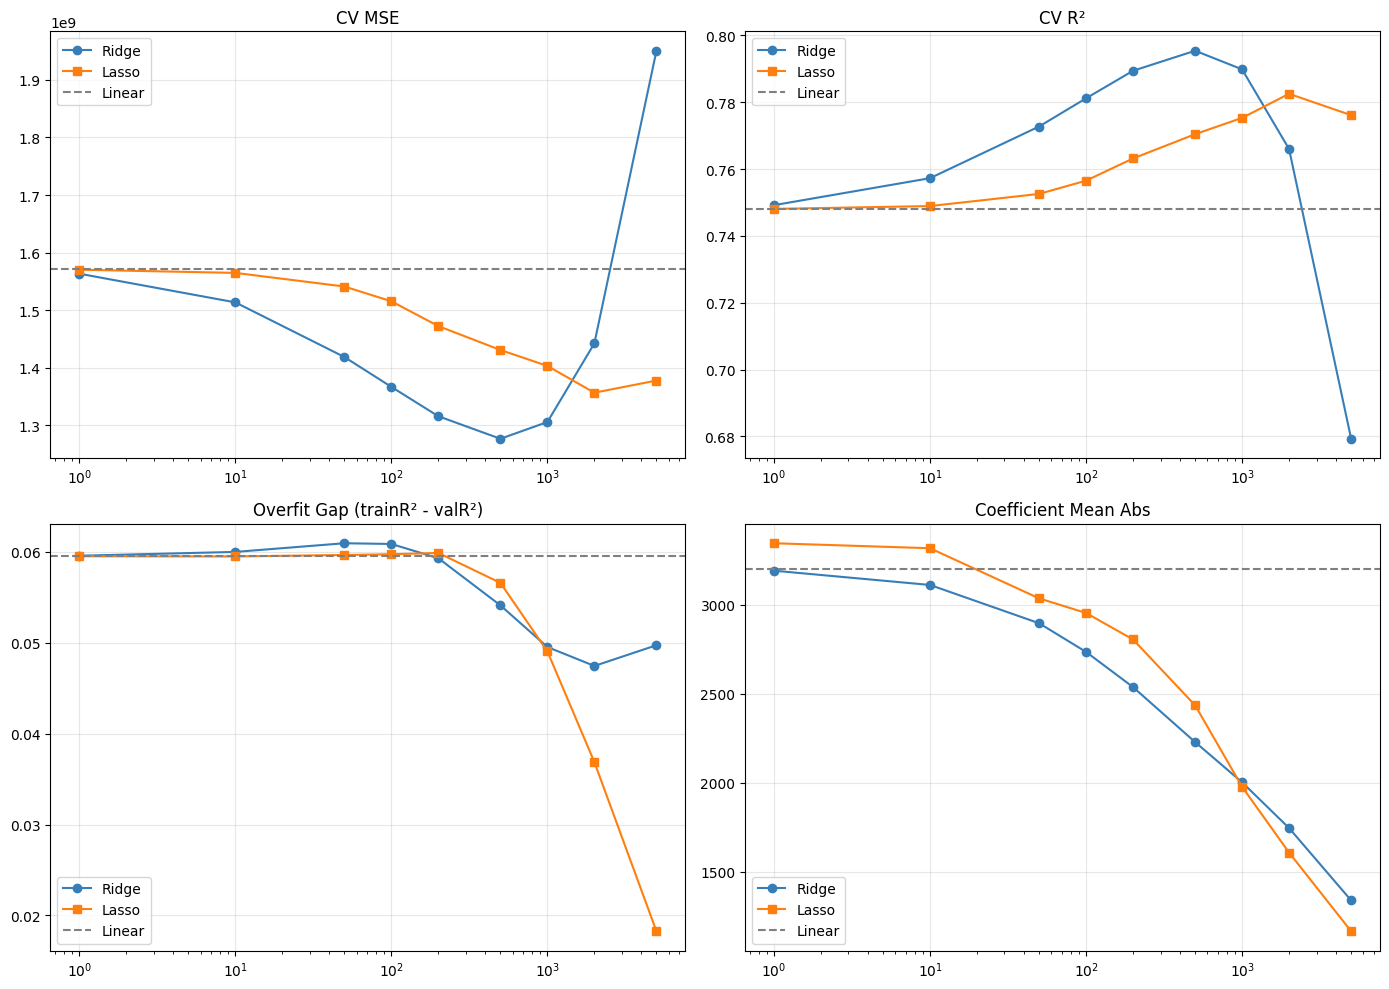

In [9]:
df = pd.DataFrame(results)

# 提取数据
ridge = df[df["model"] == "Ridge"]
lasso = df[df["model"] == "Lasso"]
linear = df[df["model"] == "Linear"].iloc[0]

# 重置 matplotlib 设置，不加载任何中文字体
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams["axes.unicode_minus"] = False

# 画图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. CV MSE
axes[0,0].plot(ridge["alpha"], ridge["cv_mse"], marker='o', label='Ridge', color='#377eb8')
axes[0,0].plot(lasso["alpha"], lasso["cv_mse"], marker='s', label='Lasso', color='#ff7f0e')
axes[0,0].axhline(linear["cv_mse"], linestyle='--', color='gray', label='Linear')
axes[0,0].set_xscale('log')
axes[0,0].set_title('CV MSE')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# 2. CV R²
axes[0,1].plot(ridge["alpha"], ridge["cv_r2"], marker='o', label='Ridge', color='#377eb8')
axes[0,1].plot(lasso["alpha"], lasso["cv_r2"], marker='s', label='Lasso', color='#ff7f0e')
axes[0,1].axhline(linear["cv_r2"], linestyle='--', color='gray', label='Linear')
axes[0,1].set_xscale('log')
axes[0,1].set_title('CV R²')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Overfit Gap
axes[1,0].plot(ridge["alpha"], ridge["gap"], marker='o', label='Ridge', color='#377eb8')
axes[1,0].plot(lasso["alpha"], lasso["gap"], marker='s', label='Lasso', color='#ff7f0e')
axes[1,0].axhline(linear["gap"], linestyle='--', color='gray', label='Linear')
axes[1,0].set_xscale('log')
axes[1,0].set_title('Overfit Gap (trainR² - valR²)')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# 4. Coefficient Mean Abs
axes[1,1].plot(ridge["alpha"], ridge["coef_mean"], marker='o', label='Ridge', color='#377eb8')
axes[1,1].plot(lasso["alpha"], lasso["coef_mean"], marker='s', label='Lasso', color='#ff7f0e')
axes[1,1].axhline(linear["coef_mean"], linestyle='--', color='gray', label='Linear')
axes[1,1].set_xscale('log')
axes[1,1].set_title('Coefficient Mean Abs')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("原始特征列名（全部）:")
print(list(X.columns))

print("\n找到 GrLivArea 的索引位置:")
feature_name = "GrLivArea"
feature_idx = list(X.columns).index(feature_name)
print(f"GrLivArea 在第 {feature_idx} 列")

print("\n查看 X_train 形状:", X_train.shape)
print("取到的单变量特征形状:", X_train[:, feature_idx:feature_idx+1].shape)


原始特征列名（全部）:
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'P

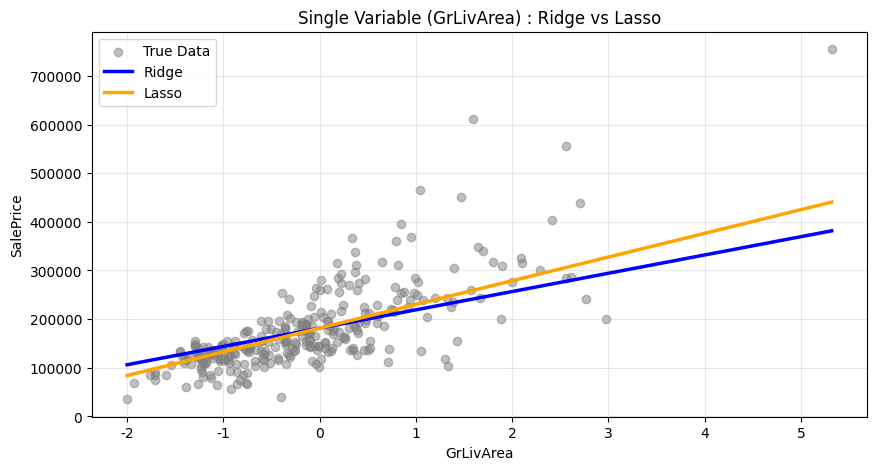

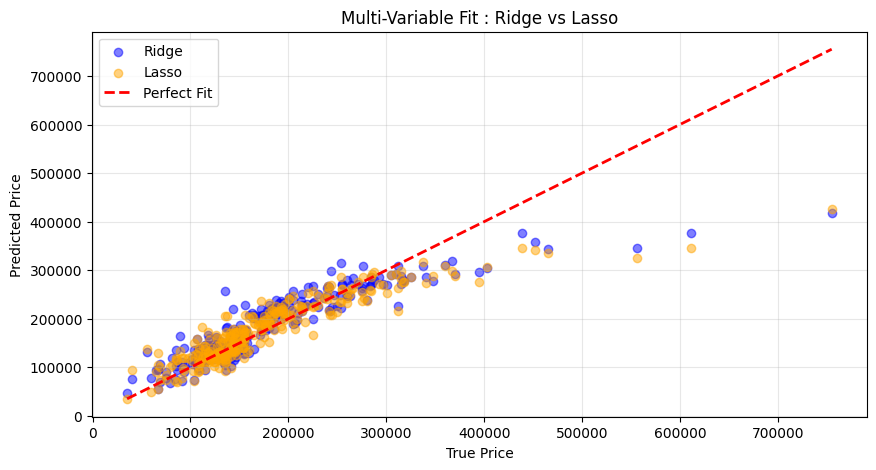

In [11]:
# 你指定的最优模型
best_ridge = Ridge(alpha=500)
best_lasso = Lasso(alpha=5000, max_iter=50000, tol=1e-3)

# 单变量特征 GrLivArea
feature_name = "GrLivArea"
feature_idx = list(X.columns).index(feature_name)

X_train_1d = X_train[:, feature_idx:feature_idx+1]
X_val_1d = X_val[:, feature_idx:feature_idx+1]

# 训练两个单变量模型
ridge_1d = Ridge(alpha=500)
lasso_1d = Lasso(alpha=5000, max_iter=50000, tol=1e-3)
ridge_1d.fit(X_train_1d, y_train)
lasso_1d.fit(X_train_1d, y_train)

# 排序后画线（保证直线平滑）
x_sorted = np.sort(X_val_1d, axis=0)
y_ridge_1d = ridge_1d.predict(x_sorted)
y_lasso_1d = lasso_1d.predict(x_sorted)

# 多变量预测
best_ridge.fit(X_train, y_train)
best_lasso.fit(X_train, y_train)
y_ridge_multi = best_ridge.predict(X_val)
y_lasso_multi = best_lasso.predict(X_val)

# ===================== 图1：单变量回归直线对比 =====================
plt.figure(figsize=(10, 5))
plt.scatter(X_val_1d, y_val, alpha=0.5, color='gray', label='True Data')
plt.plot(x_sorted, y_ridge_1d, 'b-', linewidth=2.5, label='Ridge')
plt.plot(x_sorted, y_lasso_1d, 'orange', linewidth=2.5, label='Lasso')
plt.title('Single Variable (GrLivArea) : Ridge vs Lasso')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ===================== 图2：多变量拟合对比 =====================
plt.figure(figsize=(10, 5))
plt.scatter(y_val, y_ridge_multi, alpha=0.5, color='blue', label='Ridge')
plt.scatter(y_val, y_lasso_multi, alpha=0.5, color='orange', label='Lasso')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', linewidth=2, label='Perfect Fit')
plt.title('Multi-Variable Fit : Ridge vs Lasso')
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
# 1. 普通线性回归梯度下降
def gd_linear(X, y, lr, max_iter=800):
    n, p = X.shape
    w = np.zeros(p)
    b = 0.0
    loss_list = []
    for _ in range(max_iter):
        y_pred = X @ w + b
        mse = np.mean((y_pred - y) ** 2)
        loss_list.append(mse)
        dw = (1/n) * X.T @ (y_pred - y)
        db = (1/n) * np.sum(y_pred - y)
        w -= lr * dw
        b -= lr * db
    return loss_list

# 2. Ridge L2
# def gd_ridge(X, y, lr, alpha=500, max_iter=800):
#     n, p = X.shape
#     w = np.zeros(p)
#     b = 0.0
#     loss_list = []
#     for _ in range(max_iter):
#         y_pred = X @ w + b
#         mse = np.mean((y_pred - y) ** 2)
#         loss = mse + alpha * np.sum(w ** 2)
#         loss_list.append(loss)
#         dw = (1/n) * X.T @ (y_pred - y) + 2 * alpha * w
#         db = (1/n) * np.sum(y_pred - y)
#         w -= lr * dw
#         b -= lr * db
#     return loss_list

# # 3. Lasso L1
# def gd_lasso(X, y, lr, alpha=5000, max_iter=800):
#     n, p = X.shape
#     w = np.zeros(p)
#     b = 0.0
#     loss_list = []
#     for _ in range(max_iter):
#         y_pred = X @ w + b
#         mse = np.mean((y_pred - y) ** 2)
#         loss = mse + alpha * np.sum(np.abs(w))
#         loss_list.append(loss)
#         dw = (1/n) * X.T @ (y_pred - y) + alpha * np.sign(w)
#         db = (1/n) * np.sum(y_pred - y)
#         w -= lr * dw
#         b -= lr * db
#     return loss_list
def calc_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

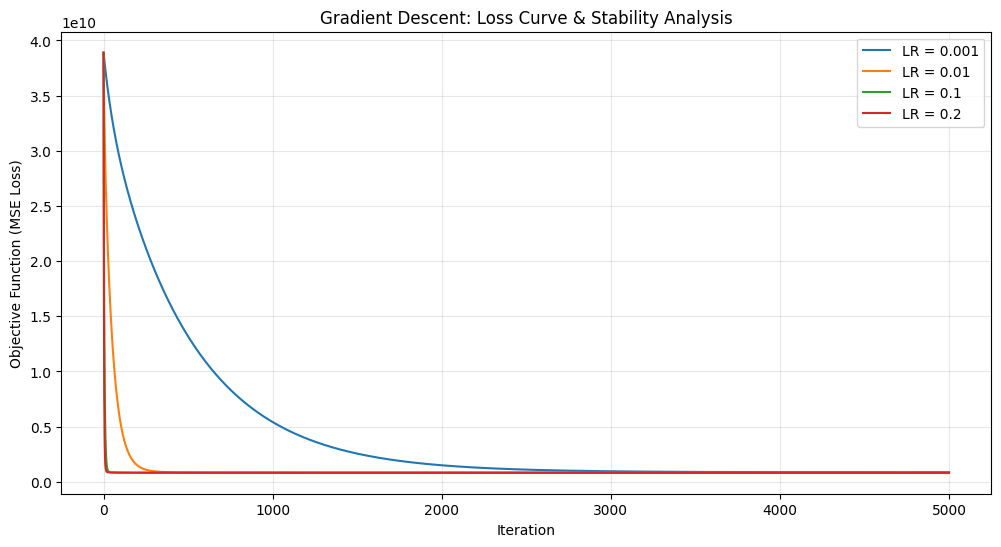

In [13]:
lr_list = [0.001, 0.01, 0.1,0.2]
max_iter = 5000

plt.figure(figsize=(12, 6))
# 循环绘制不同学习率的损失曲线
for lr in lr_list:
    loss = gd_linear(X_train, y_train, lr=lr, max_iter=max_iter)
    plt.plot(loss, label=f'LR = {lr}')

# 绘图标签（纯英文，作业规范）
plt.title("Gradient Descent: Loss Curve & Stability Analysis")
plt.xlabel("Iteration")
plt.ylabel("Objective Function (MSE Loss)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()